In [51]:
## Michael Stern's Jupyter notebook for Berkeley AI/ML Course
## Capstone Project Final Submission

In [52]:
# Exploratory Data Analysis and Feature Engineering

In [53]:
# import the dataset
# Data source: 
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi%3A10.7910%2FDVN%2FJQGLHX&version=&q=&fileAccess=&fileTag=&fileSortField=&fileSortOrder=&tagPresort=true&folderPresort=true

import pandas as pd

fa_df = pd.read_csv('ppd_stage1_stage2.txt', sep='\t')

print(fa_df.head())


  donor country_code_WB countryname_WB              region  startyear  \
0  AfDB             AGO         Angola  Sub-Saharan Africa     2003.0   
1  AfDB             AGO         Angola  Sub-Saharan Africa     2008.0   
2  AfDB             AGO         Angola  Sub-Saharan Africa     2011.0   
3  AfDB             AGO         Angola  Sub-Saharan Africa     2014.0   
4  AfDB             BDI        Burundi                 NaN     1974.0   

   original_overall_rating  six_overall_rating  countryiddummy  donoriddummy  \
0                 2.707317            4.060976             4.0           1.0   
1                 2.940000            4.410000             4.0           1.0   
2                 3.300000            4.950000             4.0           1.0   
3                 3.000000            4.500000             4.0           1.0   
4                      NaN                 NaN            19.0           1.0   

   regioniddummy  ...  afdb_projectamount_usd  pseudo_sector  \
0            7.0

/tmp/ipykernel_164/537298403.py:7: DtypeWarning: Columns (87,88,89,90,91,92) have mixed types. Specify dtype option on import or set low_memory=False.
  fa_df = pd.read_csv('ppd_stage1_stage2.txt', sep='\t')


In [54]:
fa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21788 entries, 0 to 21787
Data columns (total 93 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   donor                        21788 non-null  object 
 1   country_code_WB              20475 non-null  object 
 2   countryname_WB               21252 non-null  object 
 3   region                       20369 non-null  object 
 4   startyear                    21684 non-null  float64
 5   original_overall_rating      20689 non-null  float64
 6   six_overall_rating           20686 non-null  float64
 7   countryiddummy               20475 non-null  float64
 8   donoriddummy                 21788 non-null  float64
 9   regioniddummy                20369 non-null  float64
 10  donor_country                20475 non-null  float64
 11  region_donor                 20302 non-null  float64
 12  countrytrend                 20375 non-null  float64
 13  donortrend      

In [55]:
# Delete lagged variables to simplify analysis
# and to account for participant's lack of expertise in how to use these variables

# define sequence of letters to drop for columns starting with "lag"
prefix_to_drop1 = 'lag'

# Identify columns to drop using list comprehension
columns_to_drop1 = [col for col in fa_df.columns if col.startswith(prefix_to_drop1)]

# Drop the identified columns
fa_df = fa_df.drop(columns = columns_to_drop1)

# define sequence of letters to drop for columns starting with "lead"
prefix_to_drop2 = 'lead'

# Identify columns to drop using list comprehension
columns_to_drop2 = [col for col in fa_df.columns if col.startswith(prefix_to_drop2)]

# Drop the identified columns
fa_df = fa_df.drop(columns = columns_to_drop2)

fa_df.info()
# dropped 44 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21788 entries, 0 to 21787
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   donor                        21788 non-null  object 
 1   country_code_WB              20475 non-null  object 
 2   countryname_WB               21252 non-null  object 
 3   region                       20369 non-null  object 
 4   startyear                    21684 non-null  float64
 5   original_overall_rating      20689 non-null  float64
 6   six_overall_rating           20686 non-null  float64
 7   countryiddummy               20475 non-null  float64
 8   donoriddummy                 21788 non-null  float64
 9   regioniddummy                20369 non-null  float64
 10  donor_country                20475 non-null  float64
 11  region_donor                 20302 non-null  float64
 12  countrytrend                 20375 non-null  float64
 13  donortrend      

In [56]:
# delete null values for the target variable six_overall_rating

fa_df.dropna(subset=['six_overall_rating'], inplace = True)
fa_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20686 entries, 0 to 21786
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   donor                        20686 non-null  object 
 1   country_code_WB              19945 non-null  object 
 2   countryname_WB               20686 non-null  object 
 3   region                       19892 non-null  object 
 4   startyear                    20602 non-null  float64
 5   original_overall_rating      20686 non-null  float64
 6   six_overall_rating           20686 non-null  float64
 7   countryiddummy               19945 non-null  float64
 8   donoriddummy                 20686 non-null  float64
 9   regioniddummy                19892 non-null  float64
 10  donor_country                19945 non-null  float64
 11  region_donor                 19826 non-null  float64
 12  countrytrend                 19864 non-null  float64
 13  donortrend           

In [57]:
# drop variables not needed as input for ML models

# original_overall_rating (using six_overall_rating as target variable 
# since it is standardized across different rating scales)

# 'pseudo_sector' (project sector information captured by 'wb_sector_board')
# 'crs_purpose_sector' (project sector information captured by 'wb_sectorboard')
# dfat_InvestmentPriorityArea (captured by 'wb_sector_board')
# ifad_Subsector (captured by 'wb_sector_board')
# gfatm_project_component (captured by 'wb_sector_board')
# wb_sectorboard (captured by 'wb_sector_board')
# gef_FocalArea (captured by 'wb_sector_board')
# afdb_SectorNames (captured by 'wb_sector_board')
# startyear (using 'project_duration' to capture info about project timing)

# countrytrend
# donortrend
# year_info_pol (captured by 'info_pol')
# year_info_app (captured by 'info_app')
# region_donor
# donor_country (captured by 'donor')
# classification

fa_df = fa_df.drop(columns = ['original_overall_rating', 'pseudo_sector', 'crs_purpose_sector', 'dfat_InvestmentPriorityArea', 
                              'ifad_Subsector', 'gfatm_project_component', 'wb_sectorboard',
                              'gef_FocalArea', 'afdb_SectorNames', 'startyear',
                             'countrytrend', 'donortrend', 'year_info_pol',
                             'year_info_app', 'region_donor', 'donor_country', 
                             'classification'])

fa_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 20686 entries, 0 to 21786
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   donor                       20686 non-null  object 
 1   country_code_WB             19945 non-null  object 
 2   countryname_WB              20686 non-null  object 
 3   region                      19892 non-null  object 
 4   six_overall_rating          20686 non-null  float64
 5   countryiddummy              19945 non-null  float64
 6   donoriddummy                20686 non-null  float64
 7   regioniddummy               19892 non-null  float64
 8   gdp_growth                  18957 non-null  float64
 9   oda_to_gni                  18111 non-null  float64
 10  gdp_percapita               18983 non-null  float64
 11  info_app                    20602 non-null  float64
 12  info_pol                    20602 non-null  float64
 13  eval_ind                    20602 no

In [58]:
# Drop project size columns specific to a donor
# 'projectsize_original' captures all the project size information required

fa_df = fa_df.drop(columns = ['asdb_approvedamount', 'jica_projectsize', 'kfw_projectsize',
                              'giz_projectsize', 'ifad_LoanAmount', 'gfatm_grantdisbursedamount',
                              'gef_grant_mil_usd', 'wb_lendingprojectcost', 'afdb_projectamount_usd']) 

fa_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20686 entries, 0 to 21786
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   donor                 20686 non-null  object 
 1   country_code_WB       19945 non-null  object 
 2   countryname_WB        20686 non-null  object 
 3   region                19892 non-null  object 
 4   six_overall_rating    20686 non-null  float64
 5   countryiddummy        19945 non-null  float64
 6   donoriddummy          20686 non-null  float64
 7   regioniddummy         19892 non-null  float64
 8   gdp_growth            18957 non-null  float64
 9   oda_to_gni            18111 non-null  float64
 10  gdp_percapita         18983 non-null  float64
 11  info_app              20602 non-null  float64
 12  info_pol              20602 non-null  float64
 13  eval_ind              20602 non-null  float64
 14  recipient_fia         19714 non-null  float64
 15  recipient_fia_appeal  19

In [59]:
# Target variable is continuous so regression model appropriate
# Address presence of categorical features

# Drop columns related to country receiving foreign aid 
    # to avoid creating large sparse matrix during encoding
fa_df = fa_df.drop(columns = ['countryname_WB', 'country_code_WB',
                                'countryiddummy', 'regioniddummy'])

# Drop existing dummy variable columns related to donor 
# Current encoding makes interpreting results very challenging
fa_df = fa_df.drop(columns = ['donoriddummy'])

# Drop recipient country region as a feature 
# Diversity of countries within a given region make region unsuitable to use
fa_df = fa_df.drop(columns = ['region'])

# Create dummy variable columns for foreign aid donor and project sector
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define a column transformer with the encoder
transformer = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(), ['donor', 'wb_sector_board'])
], remainder='passthrough')

# Fit and transform (with conversion to dataframe)
encoded_array = transformer.fit_transform(fa_df)

# Get the new column names for the dummy variables
new_col_names = transformer.get_feature_names_out()

# Create the final integrated DataFrame
fa_df_encoded = pd.DataFrame(encoded_array, columns = new_col_names)

# Combine (concatenate) the newly encoded columns into existing dataframe
final_df = pd.concat([fa_df, fa_df_encoded], axis=1)

# Drop remaining categorical columns, missing value columns, 
    # and duplicate columns created during encoding and concatenation
final_df = final_df.drop(columns = ['donor', 'encoder__wb_sector_board_20.0',
                                   'wb_sector_board'])
cols_to_drop = [c for c in final_df.columns if c.startswith('remainder')]
final_df = final_df.drop(columns = cols_to_drop)

final_df.info()
# confirm that all features are not categorical  

<class 'pandas.core.frame.DataFrame'>
Index: 21755 entries, 0 to 20525
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   six_overall_rating             20686 non-null  float64
 1   gdp_growth                     18957 non-null  float64
 2   oda_to_gni                     18111 non-null  float64
 3   gdp_percapita                  18983 non-null  float64
 4   info_app                       20602 non-null  float64
 5   info_pol                       20602 non-null  float64
 6   eval_ind                       20602 non-null  float64
 7   recipient_fia                  19714 non-null  float64
 8   recipient_fia_appeal           19714 non-null  float64
 9   civsocprcp                     19344 non-null  float64
 10  press_score                    11923 non-null  float64
 11  wgi_corrup_control             9143 non-null   float64
 12  wgi_rule_of_law                9157 non-null   floa

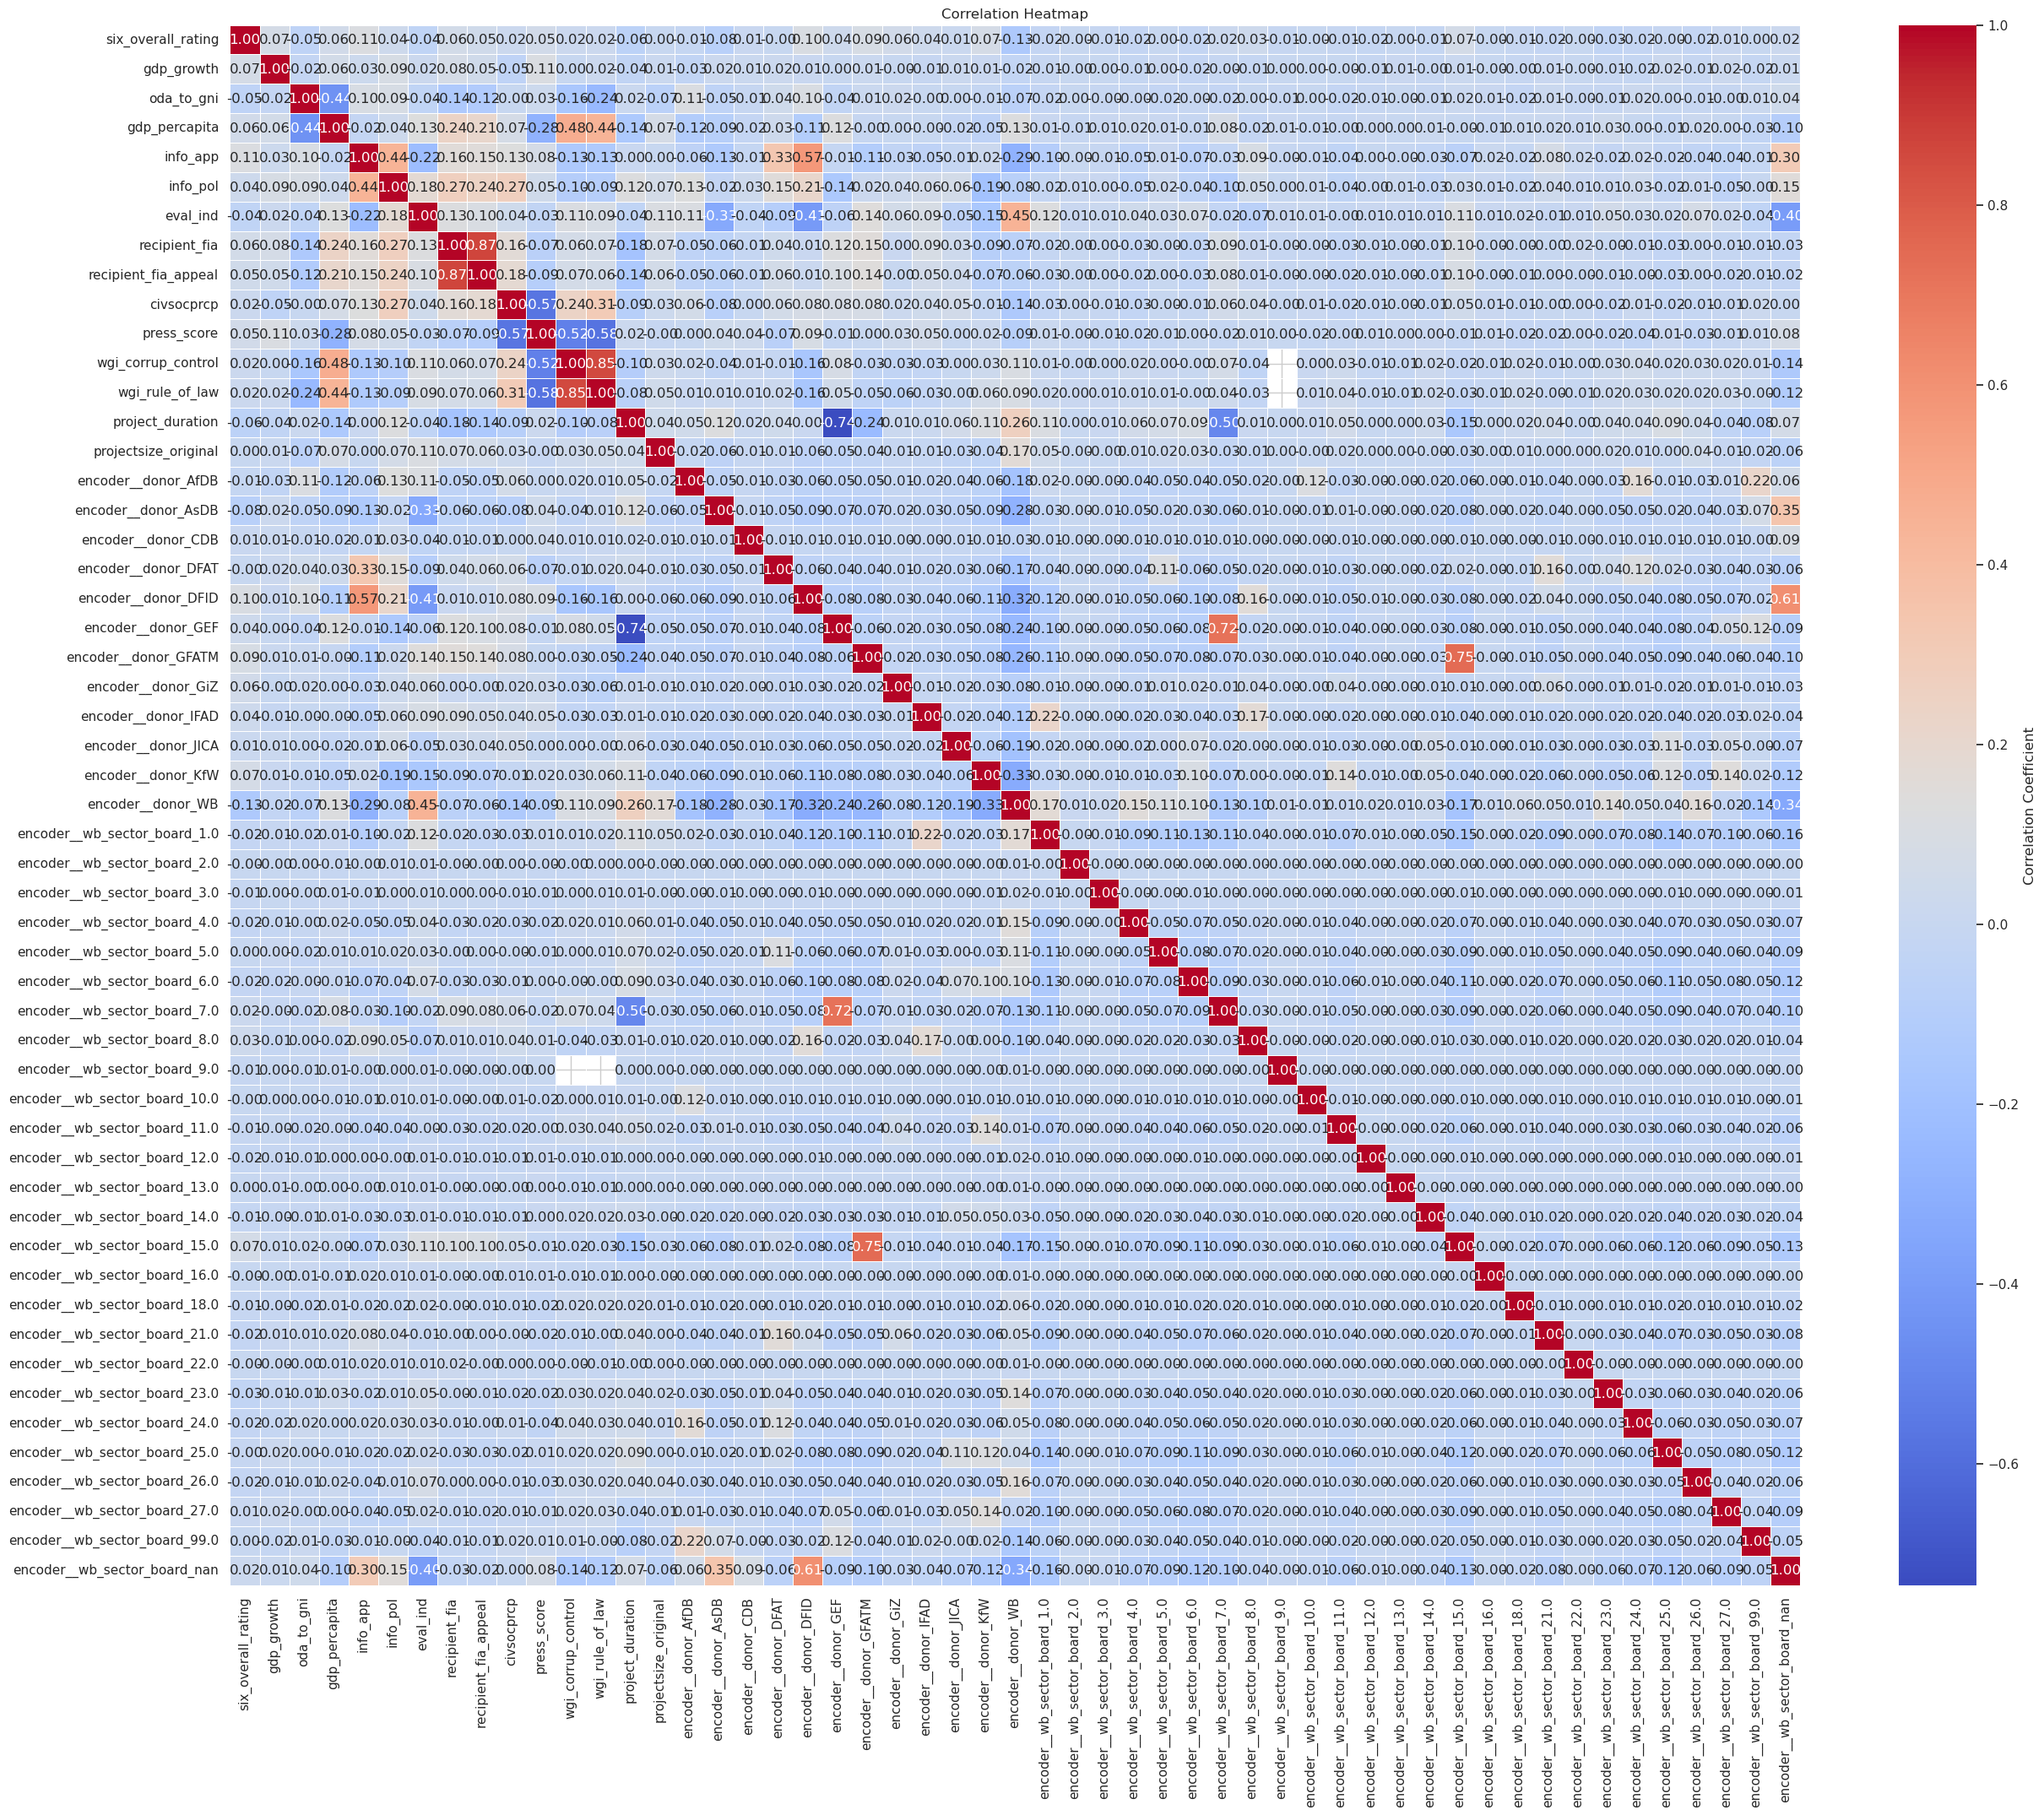

<Figure size 640x480 with 0 Axes>

In [60]:
# correlation heatmap to explore relationships between variables

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = final_df.corr()

plt.figure(figsize=(30, 24))
sns.heatmap(
    correlation_matrix,
    annot=True,        # Show the correlation values on the map
    fmt=".2f",         # Format the values to two decimal places
    cmap='coolwarm',   # color palette
    linewidths=.5,     
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap')
plt.show()
plt.savefig('correlation_heatmap.jpg', dpi = 300)

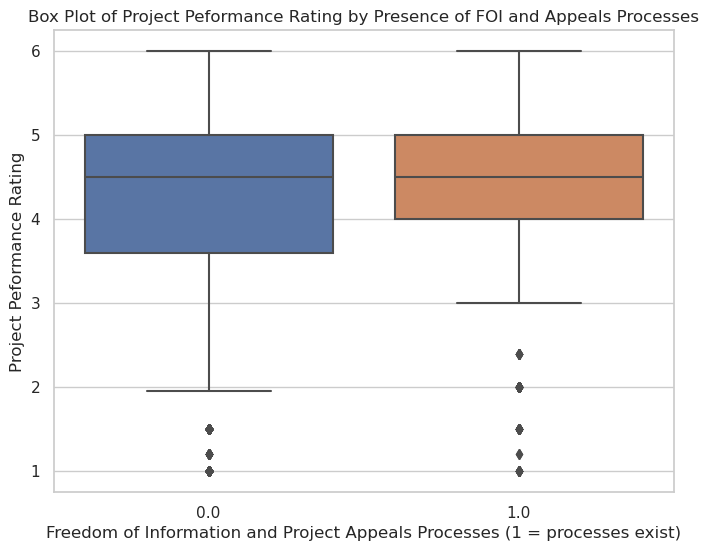

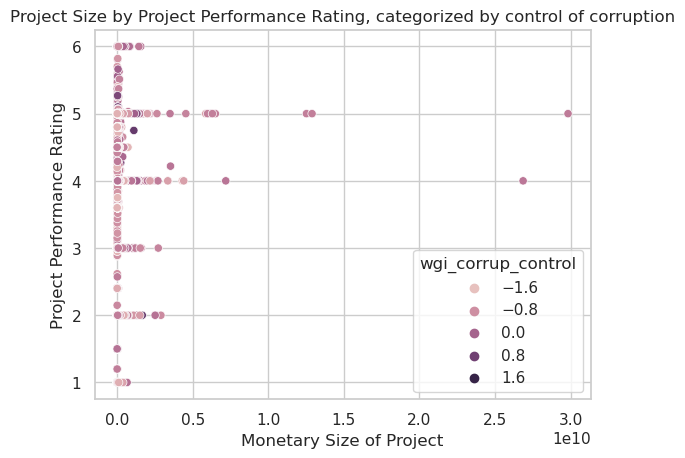

<Figure size 640x480 with 0 Axes>

In [61]:
# plots to examine how features potentially influence the target "six_overall_rating

plt.figure(figsize=(8, 6))
sns.boxplot(x = 'recipient_fia_appeal', y = 'six_overall_rating', data = final_df)
plt.title('Box Plot of Project Peformance Rating by Presence of FOI and Appeals Processes')
plt.xlabel('Freedom of Information and Project Appeals Processes (1 = processes exist)')
plt.ylabel('Project Peformance Rating')
plt.show()
# indication that having an FOI mechanism and appeals mechanism associated with higher ratings on avg

sns.scatterplot(x = 'projectsize_original', y = 'six_overall_rating', data= final_df, hue = 'wgi_corrup_control')

plt.title('Project Size by Project Performance Rating, categorized by control of corruption')
plt.xlabel('Monetary Size of Project')
plt.ylabel('Project Performance Rating')

plt.show()
plt.savefig('scatter_projperf_corrup.jpg', dpi=300)

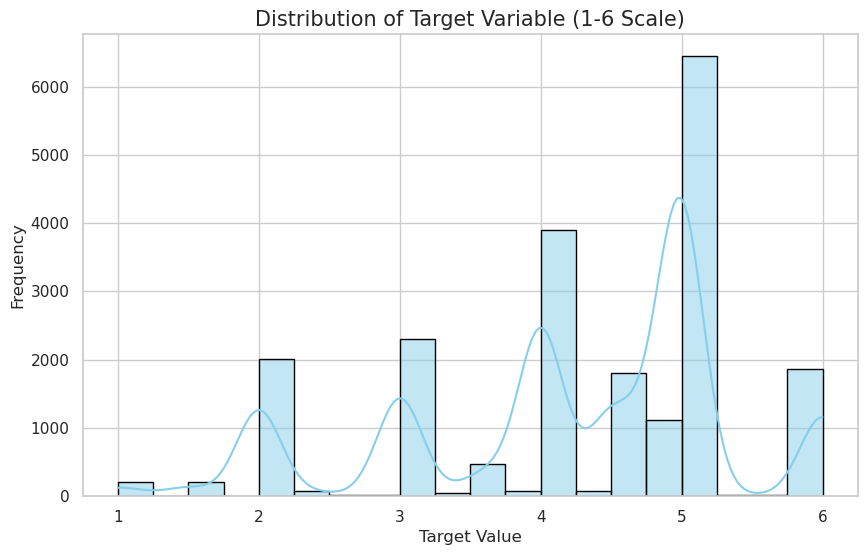

<Figure size 640x480 with 0 Axes>

In [62]:
# Histogram of the target variable

# Set plot style
sns.set_theme(style="whitegrid")

# Create and label plot
plt.figure(figsize=(10, 6))
sns.histplot(final_df['six_overall_rating'], 
             bins=20,
             binrange=(1, 6),     # limit the x-axis scale
             kde=True,            # Adds a smooth density line
             color='skyblue',
             edgecolor='black')
plt.title('Distribution of Target Variable (1-6 Scale)', fontsize=15)
plt.xlabel('Target Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()
plt.savefig('target_histogram.jpg', dpi=300)

In [63]:
# Linear Regression as baseline model
# Target feature 'six_overall_rating' is continuous

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# drop null row values
final_df.dropna(inplace = True)

# Columns for features and target
X = final_df[['six_overall_rating', 'gdp_growth', 
                   'oda_to_gni', 'gdp_percapita', 'info_app',
                   'info_pol', 'eval_ind', 'recipient_fia',
                   'recipient_fia_appeal', 'civsocprcp', 'press_score',
                   'wgi_corrup_control', 'wgi_rule_of_law', 'project_duration',
                   'projectsize_original', 
                   'encoder__donor_AfDB', 'encoder__donor_AsDB',
                   'encoder__donor_CDB', 'encoder__donor_DFAT',
                   'encoder__donor_DFID', 'encoder__donor_GEF',
                   'encoder__donor_GFATM', 'encoder__donor_GiZ',
                   'encoder__donor_IFAD', 'encoder__donor_JICA',
                   'encoder__donor_KfW', 'encoder__donor_WB',
                    'encoder__wb_sector_board_1.0', 'encoder__wb_sector_board_3.0',
                   'encoder__wb_sector_board_4.0', 'encoder__wb_sector_board_5.0',
                   'encoder__wb_sector_board_6.0', 'encoder__wb_sector_board_7.0',
                   'encoder__wb_sector_board_8.0', 'encoder__wb_sector_board_9.0',
                   'encoder__wb_sector_board_10.0', 'encoder__wb_sector_board_11.0',
                   'encoder__wb_sector_board_12.0', 'encoder__wb_sector_board_13.0',
                   'encoder__wb_sector_board_14.0', 'encoder__wb_sector_board_15.0',
                   'encoder__wb_sector_board_16.0', 'encoder__wb_sector_board_18.0',
                   'encoder__wb_sector_board_21.0', 'encoder__wb_sector_board_22.0',
                   'encoder__wb_sector_board_23.0', 'encoder__wb_sector_board_24.0',
                   'encoder__wb_sector_board_25.0', 'encoder__wb_sector_board_26.0',
                   'encoder__wb_sector_board_27.0', 'encoder__wb_sector_board_99.0']] # features
y = final_df['six_overall_rating'] # target

# Training-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state = 42)

# Create and fit basic Linear Regression model
model = LinearRegression().fit(X_train, y_train)

# Verify the split
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


Training set size: 6037 rows
Test set size: 1510 rows
Mean Squared Error: 2.2728861863842565e-15
Coefficients: [ 1.00000000e+00 -6.50859767e-11  2.40060321e-10  6.91182343e-10
  2.56388065e-08  2.93601675e-08 -5.48638145e-08  4.45053592e-09
 -1.42688073e-08 -7.94808858e-10 -7.23105179e-11 -2.89625220e-08
  2.49320644e-08 -4.36333151e-12  3.10554888e-19 -2.18518057e-08
  2.54042264e-08 -1.36684892e-07  2.00802502e-07 -6.19721611e-08
 -1.35672400e-07  6.68207696e-08  1.83936373e-08  6.68279963e-10
  1.15996048e-08  3.03514002e-08  2.14083965e-09  4.77859588e-08
  1.87595165e-07 -1.90533956e-08  6.08195422e-08 -1.65503138e-08
  1.51187878e-07 -7.36224059e-08  9.86076132e-32 -1.61644966e-07
  1.01366278e-07  4.17641792e-08 -7.99909493e-08  8.32773069e-08
  1.70353270e-09  5.32044093e-09  4.09544378e-08  9.88584279e-08
 -2.46519033e-32  2.74314991e-08  4.77386108e-09  5.35560386e-08
  5.82449794e-08  2.67294546e-08  2.49467347e-08]
Intercept: -1.5849098033982045e-08


In [64]:
# Run a Random Forests Regression Model with Out-of-Bag Score

from sklearn.ensemble import RandomForestRegressor

# Initialize and fit the model on full dataframe to see OOB score
RF_oob_model = RandomForestRegressor(n_estimators = 200, max_features = 10,
                                     oob_score = True, 
                                     random_state = 42).fit(X, y)

print(f"OOB Score: {RF_oob_model.oob_score_:.4f}")

OOB Score: 0.9796


In [65]:
# Run a Random Forests Regression Model using train-test split
# Tune hyperparameters using GridSearch

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

# Initialize the regression model
RF_gridsearch_model = RandomForestRegressor(random_state = 42)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': [None]      # uses all features
}

# Set up and fit the Grid Search
# Using the MAE for easier interpretation of the model results
grid_search = GridSearchCV(
    estimator = RF_gridsearch_model, 
    param_grid = param_grid, 
    cv = 5, 
    scoring='neg_mean_absolute_error', 
    n_jobs = -1).fit(X_train, y_train)

# View results
print(f"Best Params: {grid_search.best_params_}")
# MAE for the training data (multiplied by -1 for easier interpretation)
print(f"Best MAE for training data: {-grid_search.best_score_:.3f}")

# Calculate predicted values on the test data using optimal parameters
best_rf = grid_search.best_estimator_
predictions = best_rf.predict(X_test)

# MAE calculation for the test set
test_mae = mean_absolute_error(y_test, predictions)

print(f"MAE score for test data: {test_mae:.3f}")


Best Params: {'max_depth': 10, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 300}
Best MAE for training data: 0.001
MAE score for test data: 0.001


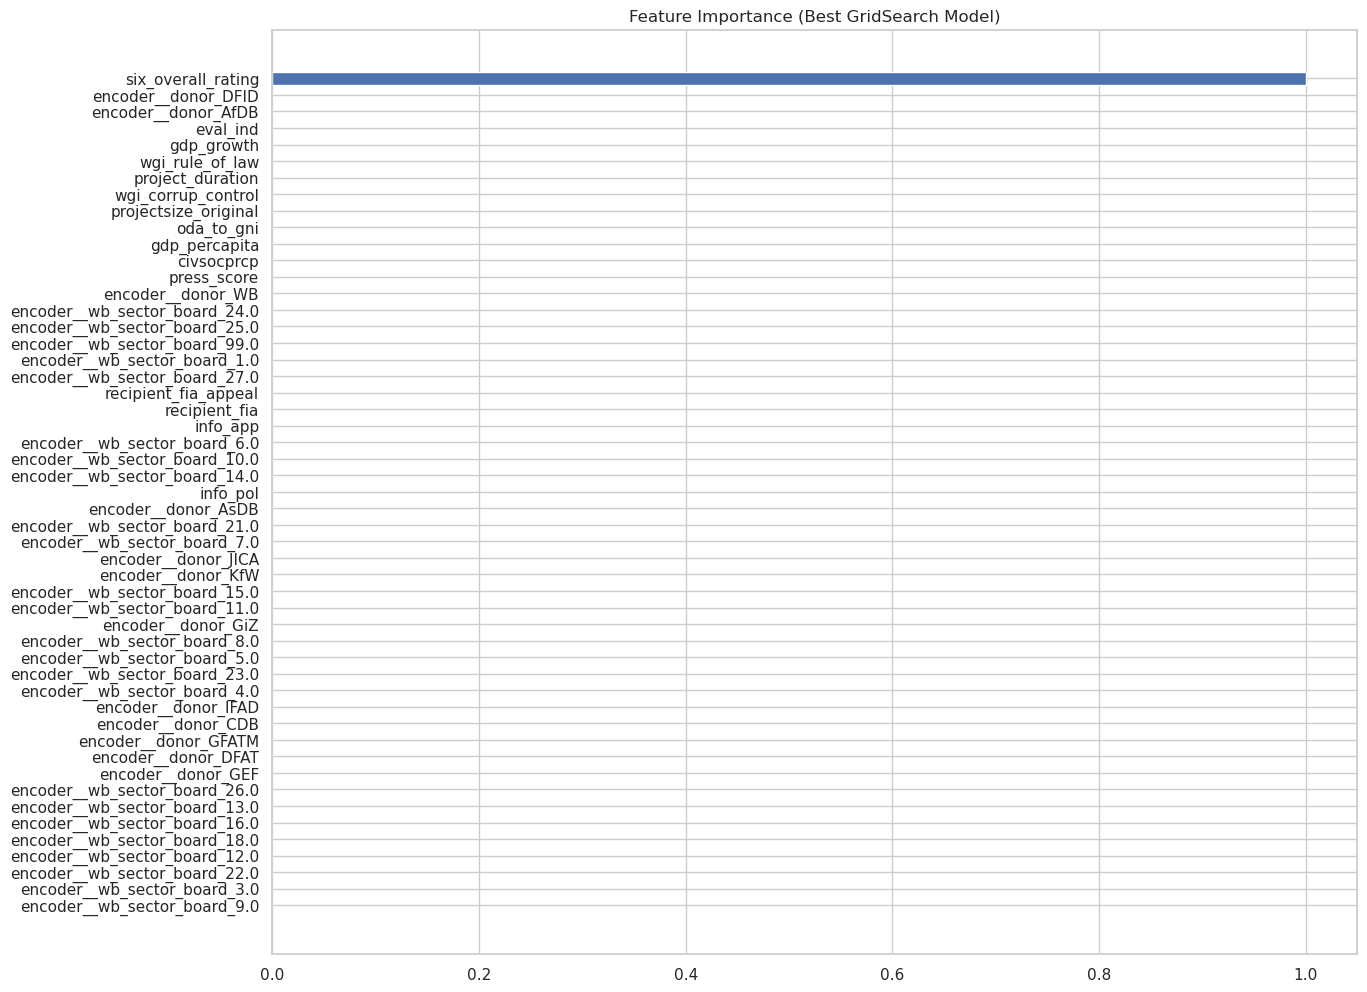

<Figure size 640x480 with 0 Axes>

In [66]:
# Understanding what features have the most influence on the target

import matplotlib.pyplot as plt

# Use the best model generated by GridSearch to get importance scores
importances = best_rf.feature_importances_

# Align scores with with column names
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

# Sort the scores; plot
feature_importance_df = feature_importance_df.sort_values(by = 'Importance',
                                                          ascending = False)

plt.figure(figsize=(14, 12))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance (Best GridSearch Model)')
plt.show()
plt.savefig('feature_importance.jpg', dpi=300)

In [67]:
# Develop Ridge Regression
# Comparator with Random Forest model above
# Use grid search to optimize h

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# Create Pipeline that includes scaling the data
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Define the Parameter Grid
param_grid = {
    'ridge__alpha': [0.1, 1.0, 10.0, 100.0, 500.0]
}

# Run Grid Search
# Using neg_mean_absolute_error to facilitate comparison with Random Forest model
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv = 5, 
    scoring='neg_mean_absolute_error'
)
# Fit on training data
grid_search.fit(X_train, y_train)

# Extract Best Model
best_ridge_model = grid_search.best_estimator_
print(f"Optimal alpha: {grid_search.best_params_['ridge__alpha']}")


Optimal alpha: 0.1


In [68]:
# Predictions with the optimal alpha

predictions = best_ridge_model.predict(X_test)

# Calculate MAE
mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae:.4f}")


Mean Absolute Error: 0.0000


In [69]:
# Results in terms of coefficient values

# Get feature names and coefficients
coeffs = best_ridge_model.named_steps['ridge'].coef_
features = X.columns

importance_ridge_df = pd.DataFrame({'Feature': features, 'Coefficient': coeffs})
importance_ridge_df = importance_ridge_df.sort_values(by = 'Coefficient', ascending=False)

print(importance_ridge_df)

                          Feature   Coefficient
0              six_overall_rating  1.083573e+00
21           encoder__donor_GFATM  2.631262e-06
4                        info_app  2.316092e-06
12                wgi_rule_of_law  1.997639e-06
7                   recipient_fia  1.918985e-06
10                    press_score  1.842178e-06
13               project_duration  1.809794e-06
22             encoder__donor_GiZ  1.687696e-06
20             encoder__donor_GEF  1.648149e-06
25             encoder__donor_KfW  1.618842e-06
23            encoder__donor_IFAD  8.667747e-07
1                      gdp_growth  7.559675e-07
19            encoder__donor_DFID  6.558012e-07
40  encoder__wb_sector_board_15.0  6.238255e-07
27   encoder__wb_sector_board_1.0  5.727462e-07
33   encoder__wb_sector_board_8.0  5.640610e-07
48  encoder__wb_sector_board_26.0  5.593627e-07
29   encoder__wb_sector_board_4.0  5.513984e-07
3                   gdp_percapita  5.114533e-07
36  encoder__wb_sector_board_11.0  4.688

In [70]:
# Run cross-validation to see if MAE result is consistent with the other models

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_ridge_model, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"Cross-Validated MAE: {-cv_scores.mean():.4f}")

Cross-Validated MAE: 0.0000
